<a href="https://colab.research.google.com/github/cetinazizm07/Systems-Bio-Project/blob/main/scRNAseq_analysis_NMF.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
!pip install scanpy gseapy
import scanpy as sc
import pandas as pd
import numpy as np
from sklearn.decomposition import NMF
import gseapy as gp
import matplotlib.pyplot as plt

# 1. Veriyi Yükle (Örnek olarak Scanpy'nin pbmc3k verisi)
adata = sc.datasets.pbmc3k()

# 2. Kalite Kontrol (QC) - Çok az geni olan hücreleri temizle
sc.pp.filter_cells(adata, min_genes=200)
sc.pp.filter_genes(adata, min_cells=3)

# 3. Normalizasyon (Library size etkisini kaldır)
# Her hücreyi 10,000 okumaya eşitliyoruz (CPM benzeri)
sc.pp.normalize_total(adata, target_sum=1e4)

# 4. Log-Dönüşümü (Uçurumları kapat, 0'ları koru: log(x+1))
sc.pp.log1p(adata)

# 5. Değişken Genleri Seç (Opsiyonel ama NMF'i hızlandırır)
# En çok değişim gösteren 2000 geni seçiyoruz
sc.pp.highly_variable_genes(adata, n_top_genes=2000)
adata = adata[:, adata.var.highly_variable]

print(f"İşlenecek matris boyutu: {adata.shape}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 605.3/605.3 kB 9.8 MB/s eta 0:00:00


  0%|          | 0.00/5.58M [00:00<?, ?B/s]

İşlenecek matris boyutu: (2700, 2000)


In [4]:
# Veriyi sparse matristen normal numpy dizisine çevirelim (NMF için)
# Not: Büyük verilerde bu bellek sorunu yaratabilir, o zaman sparse destekli kütüphaneler kullanılır.
X = adata.X

# Modeli Tanımla
# n_components: Kaç biyolojik süreç arıyoruz? (Şimdilik rastgele 10 diyelim)
n_bileşen = 10
nmf_model = NMF(n_components=n_bileşen, init='nndsvd', random_state=42, max_iter=500)

# Modeli Eğit
# W_hucre: Hücrelerin her bileşen için aktivite skoru (Hücre x Bileşen)
W_hucre = nmf_model.fit_transform(X)

# H_gen: Her bileşenin hangi genlerden oluştuğu (Bileşen x Gen)
H_gen = nmf_model.components_

print(f"Hücre Matrisi (W): {W_hucre.shape}") # (2xxx hücre, 10 bileşen)
print(f"Gen Matrisi (H): {H_gen.shape}")     # (10 bileşen, 2000 gen)

Hücre Matrisi (W): (2700, 10)
Gen Matrisi (H): (10, 2000)


/usr/local/lib/python3.12/dist-packages/sklearn/decomposition/_nmf.py:1742: ConvergenceWarning: Maximum number of iterations 200 reached. Increase it to improve convergence.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/decomposition/_nmf.py:1742: ConvergenceWarning: Maximum number of iterations 200 reached. Increase it to improve convergence.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/decomposition/_nmf.py:1742: ConvergenceWarning: Maximum number of iterations 200 reached. Increase it to improve convergence.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/decomposition/_nmf.py:1742: ConvergenceWarning: Maximum number of iterations 200 reached. Increase it to improve convergence.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/decomposition/_nmf.py:1742: ConvergenceWarning: Maximum number of iterations 200 reached. Increase it to improve convergence.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklea

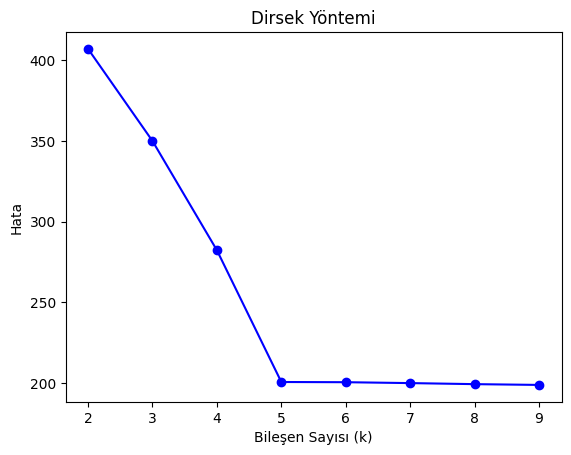

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import NMF
from sklearn.datasets import make_blobs

# --- 1. Veri Hazırlığı (Simülasyon) ---
# 500 hücre, 1000 gen ve içinde gizli 5 grup var
X, _ = make_blobs(n_samples=500, n_features=1000, centers=5, random_state=42)
X = np.abs(X) # Negatif değerleri temizle
# Normalizasyon ve Logaritma (Pipeline adımları)
X = np.log1p((X / X.sum(axis=1, keepdims=True)) * 10000)

# --- 2. Senin Tasarladığın Döngü ---
hata_skorlari = []
k_degerleri = range(2, 10) # k=2, 3, ..., 9

for k in k_degerleri:
    # Her k değeri için modeli baştan kur
    model = NMF(n_components=k, init='nndsvd', random_state=42)
    model.fit(X)

    # Hata skorunu (reconstruction_err_) listeye ekle
    hata_skorlari.append(model.reconstruction_err_)

# --- 3. Görselleştirme ---
plt.plot(k_degerleri, hata_skorlari, 'bo-')
plt.xlabel('Bileşen Sayısı (k)')
plt.ylabel('Hata')
plt.title('Dirsek Yöntemi')
plt.show()

In [6]:
import gseapy as gp

# Gen isimlerini alalım (Sütun isimleri)
gen_isimleri = adata.var_names

# Sonuçları saklamak için boş bir sözlük
bilesen_anlamlari = {}

print("Biyolojik süreçler taranıyor...")

# Her bileşen için döngü (Örnek: 5 bileşen bulmuştuk)
for bilesen_id, bilesen_gen_agirliklari in enumerate(nmf_model.components_):

    # 1. En yüksek ağırlığa sahip 50 geni bul
    # (argsort küçükten büyüğe sıralar, biz sondan 50 taneyi alıp ters çeviriyoruz)
    en_iyi_gen_indeksleri = bilesen_gen_agirliklari.argsort()[-50:][::-1]
    en_iyi_genler = gen_isimleri[en_iyi_gen_indeksleri].tolist()

    # 2. GSEA Analizi (Enrichr)
    # Veritabanı olarak 'GO_Biological_Process_2021' kullanıyoruz
    enr = gp.enrichr(gene_list=en_iyi_genler,
                     gene_sets='GO_Biological_Process_2021',
                     organism='Human',
                     outdir=None)

    # 3. En anlamlı sonucu (en düşük P-value) al
    en_iyi_sonuc = enr.res2d.iloc[0] # İlk satır en iyisidir

    bilesen_anlamlari[f"Bileşen {bilesen_id}"] = {
        "Süreç": en_iyi_sonuc['Term'],
        "P-değeri": en_iyi_sonuc['P-value'],
        "Genler": en_iyi_genler[:5] # Örnek olarak ilk 5 geni göster
    }

# Sonuçları Yazdır
for b, detay in bilesen_anlamlari.items():
    print(f"🧩 {b}: {detay['Süreç']}")
    print(f"   (P-val: {detay['P-değeri']:.2e})")
    print(f"   Genler: {detay['Genler']}\n")

Biyolojik süreçler taranıyor...
🧩 Bileşen 0: SRP-dependent cotranslational protein targeting to membrane (GO:0006614)
   (P-val: 9.50e-08)
   Genler: ['MALAT1', 'RPL13', 'B2M', 'RPS4X', 'RPS3A']

🧩 Bileşen 1: neutrophil degranulation (GO:0043312)
   (P-val: 1.87e-18)
   Genler: ['S100A9', 'FTL', 'LYZ', 'S100A8', 'FTH1']

🧩 Bileşen 2: antigen processing and presentation of exogenous peptide antigen via MHC class II (GO:0019886)
   (P-val: 4.35e-14)
   Genler: ['CD74', 'HLA-DRA', 'MALAT1', 'RPL13', 'B2M']

🧩 Bileşen 3: neutrophil chemotaxis (GO:0030593)
   (P-val: 2.08e-08)
   Genler: ['GNLY', 'NKG7', 'GZMB', 'B2M', 'PRF1']

🧩 Bileşen 4: antigen processing and presentation of exogenous peptide antigen via MHC class II (GO:0019886)
   (P-val: 4.35e-14)
   Genler: ['HLA-DPB1', 'HLA-DRB1', 'CD74', 'HLA-DRA', 'HLA-DPA1']

🧩 Bileşen 5: SRP-dependent cotranslational protein targeting to membrane (GO:0006614)
   (P-val: 9.50e-08)
   Genler: ['CCL5', 'MALAT1', 'B2M', 'NKG7', 'RPL13']

🧩 Bileşen 

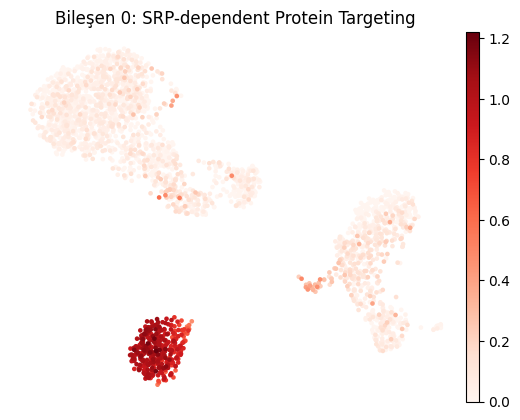

In [9]:
# 1. NMF Skorlarını AnnData nesnesine ekle
# Böylece Scanpy bunları "boyanabilir" özellikler olarak görür
for i in range(W_hucre.shape[1]):
    adata.obs[f'NMF_Bilesen_{i}'] = W_hucre[:, i]

# 2. Önce UMAP hesapla (Eğer daha önce hesaplanmadıysa)
# Scanpy önce komşuluk grafiğini (neighbors) kurar, sonra UMAP çizer
sc.pp.neighbors(adata, n_neighbors=15, n_pcs=20) # Önceki adımlardan PCA yapılmış varsayıyoruz, yoksa sc.tl.pca(adata) eklenmeli
sc.tl.umap(adata)

# 3. Haritayı Çiz (Feature Plot)
# 'Bileşen 0' (SRP Süreci) için boyama yapıyoruz
# cmap='Reds' ile skoru yüksek olan yerler koyu kırmızı parlar
sc.pl.umap(adata,
           color=['NMF_Bilesen_2'],
           cmap='Reds',
           title='Bileşen 0: SRP-dependent Protein Targeting',
           frameon=False)